## Importing Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data=pd.read_csv(r"train.csv")
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
data.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [4]:
data.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [5]:
data.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [8]:
#Explore unique values in categorical columns====
categorical_columns=data.select_dtypes(include=['object']).columns
for col in categorical_columns:
    data[col].value_counts()

In [9]:
# Check the proportion of missing values
print("\nProportion of Missing Values in Each Column:")
print((data.isnull().sum() / len(data)) * 100)


Proportion of Missing Values in Each Column:
Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Date        0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
City             0.000000
State            0.000000
Postal Code      0.112245
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.000000
dtype: float64


In [10]:

# Analyze sales by category
category_sales = data.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("\nSales by Category:\n", category_sales)


Sales by Category:
 Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


## day 2 Data Cleaning And Preprocessing

In [11]:
## handle missing values
import pandas as pd
from sklearn.impute import SimpleImputer

In [12]:
##Load the dataset
data = pd.read_csv('train.csv')

In [13]:
# Check for missing values
data.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [14]:
## columns with mean
data['Sales'].mean()


230.7690594591837

In [15]:
##columns with mode
data['Sales'].mode()

0    12.96
Name: Sales, dtype: float64

In [16]:
##columns with mode
data['Sales'].median()

54.489999999999995

In [17]:
# Forward fill to propagate the last valid observation forward
data.fillna(method='ffill', inplace=True)

C:\Users\VISWA\AppData\Local\Temp\ipykernel_5848\3039034640.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


In [18]:
# Verify no missing values remain
print("Missing Values After:\n", data.isnull().sum())

Missing Values After:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


In [19]:
## detect and remove duplicates
# Check for duplicates
print("Duplicates before removal:", data.duplicated().sum())


Duplicates before removal: 0


In [20]:
# Remove duplicates
data.drop_duplicates(inplace=True)

In [21]:
# Confirm removal
print("Duplicates after removal:", data.duplicated().sum())

Duplicates after removal: 0


In [22]:
##Normalize data
from sklearn.preprocessing import MinMaxScaler

In [23]:
scaler = MinMaxScaler()

In [24]:
## Select numerical columns
numerical_columns = data.select_dtypes(include=['float64', 'int64']).columns

In [25]:
# Apply Min-Max Scaling
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])
print("Normalized Data:\n", data[numerical_columns].head())


Normalized Data:
      Row ID  Postal Code     Sales
0  0.000000     0.421123  0.011552
1  0.000102     0.421123  0.032313
2  0.000204     0.905710  0.000626
3  0.000306     0.328421  0.042280
4  0.000408     0.328421  0.000968


In [26]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding
for column in data.select_dtypes(include=['object']):
    data[column] = label_encoder.fit_transform(data[column])

print("Label Encoded Data:\n", data.head())


Label Encoded Data:
      Row ID  Order ID  Order Date  Ship Date  Ship Mode  Customer ID  \
0  0.000000      2456         314        476          2          143   
1  0.000102      2456         314        476          2          143   
2  0.000204      2254         456        673          2          237   
3  0.000306      4295         432        774          3          705   
4  0.000408      4295         432        774          3          705   

   Customer Name  Segment  Country  City  State  Postal Code  Region  \
0            166        0        0   194     15     0.421123       2   
1            166        0        0   194     15     0.421123       2   
2            201        1        0   265      3     0.905710       3   
3            687        0        0   153      8     0.328421       2   
4            687        0        0   153      8     0.328421       2   

   Product ID  Category  Sub-Category  Product Name     Sales  
0          12         0             4           3

## EDA

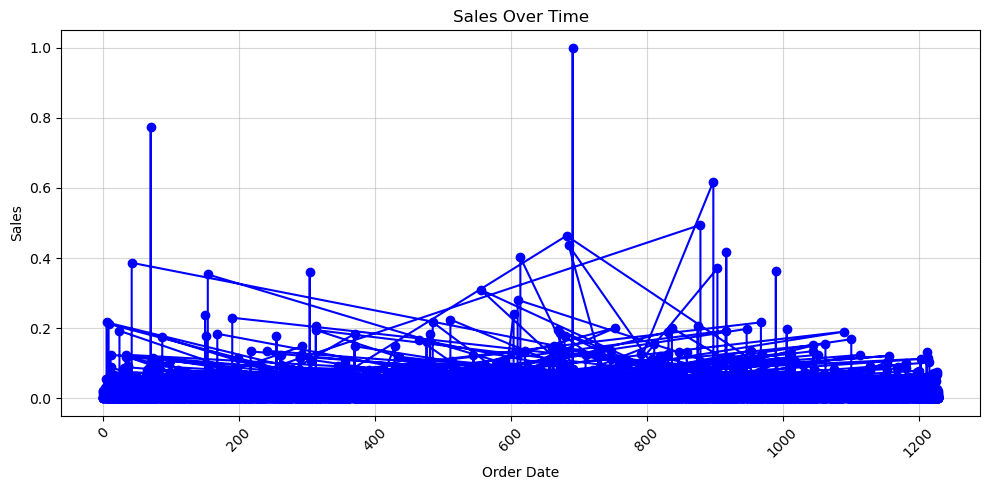

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(data['Order Date'], data['Sales'], color='blue', marker='o', linestyle='-')
plt.title('Sales Over Time')
plt.xlabel('Order Date')
plt.ylabel('Sales')
plt.grid(alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
#Ensure 'Order Date' is in datetime format
data['Order Date'] = pd.to_datetime(data['Order Date'])

In [32]:
# Create a new column for Month and Year-Month
data['Month_Num'] = data['Order Date'].dt.month
data['Month_Name'] = data['Order Date'].dt.strftime('%b')
data['Year-Month'] = data['Order Date'].dt.to_period('M')

In [33]:
# Aggregate sales by month across all years
monthly_sales = data.groupby('Month_Num')['Sales'].sum().reset_index()
monthly_sales['Month_Name'] = monthly_sales['Month_Num'].apply(lambda x: pd.Timestamp(f'2021-{x:02d}-01').strftime('%b'))

In [34]:
# Sort data by Month_Num
monthly_sales = monthly_sales.sort_values('Month_Num')

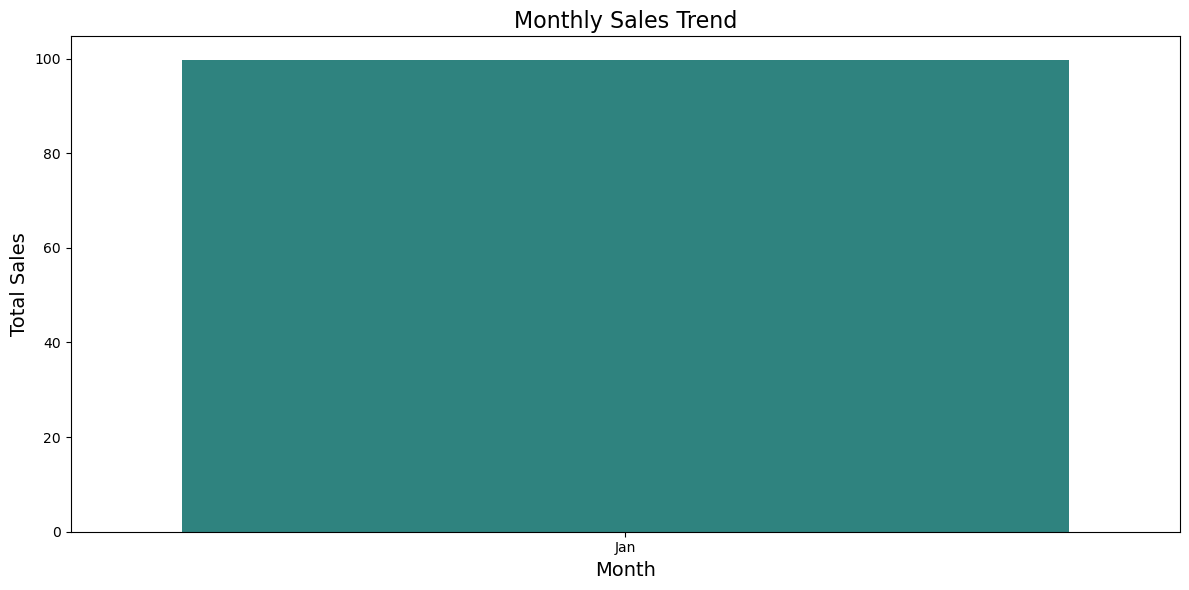

In [35]:
# Visualization : Monthly Sales Trend (Bar Plot)
plt.figure(figsize=(12, 6))
sns.barplot(x='Month_Name', y='Sales', data=monthly_sales, palette='viridis')
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Total Sales', fontsize=14)
plt.tight_layout()
plt.show()

## Day 4 Model Building

In [36]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Month_Num', 'Month_Name', 'Year-Month'],
      dtype='object')

In [54]:
x=data[['Segment','Ship Mode','Month_Num']]
y=data[['Sales']]

In [55]:
x

,Segment,Ship Mode,Month_Num
0,0,2,1
1,0,2,1
2,1,2,1
3,0,3,1
4,0,3,1
...,...,...,...
9795,1,3,1
9796,1,3,1
9797,1,3,1
9798,1,3,1


In [56]:
y

,Sales
0,0.011552
1,0.032313
2,0.000626
3,0.042280
4,0.000968
...,...
9795,0.000148
9796,0.000438
9797,0.010369
9798,0.001146


In [57]:
#train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.3,random_state=42)


In [58]:
x_train

,Segment,Ship Mode,Month_Num
9465,1,3,1
3538,1,1,1
6720,1,3,1
8807,0,3,1
7859,1,0,1
...,...,...,...
5734,1,0,1
5191,0,3,1
5390,1,2,1
860,0,3,1


In [59]:
y_train

,Sales
9465,0.001392
3538,0.000398
6720,0.006604
8807,0.001451
7859,0.001746
...,...
5734,0.001092
5191,0.001003
5390,0.001144
860,0.000306


In [60]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [71]:
pred=lr.predict(x_test)
pred

array([[0.00961941],
       [0.00961941],
       [0.00956651],
       ...,
       [0.00959296],
       [0.00946161],
       [0.00946161]])

In [72]:
print(lr.coef_)
print(lr.intercept_)

[[-1.57795392e-04  2.64492643e-05  0.00000000e+00]]
[0.00954006]


In [73]:
from sklearn.ensemble import RandomForestRegressor
rfc=RandomForestRegressor(n_estimators=10,random_state=42)
rfc
rfc.fit(x_train,y_train)

C:\Users\VISWA\AppData\Local\Temp\ipykernel_5848\1044629534.py:4: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rfc.fit(x_train,y_train)


RandomForestRegressor(n_estimators=10, random_state=42)

In [74]:
from sklearn.ensemble import RandomForestRegressor
rfc=RandomForestRegressor(n_estimators=10,random_state=42)
rfc
rfc.fit(x_train,y_train)
y_pred=rfc.predict(x_test)
y_pred

C:\Users\VISWA\AppData\Local\Temp\ipykernel_5848\3014492127.py:4: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rfc.fit(x_train,y_train)


array([0.0102491 , 0.0102491 , 0.00750564, ..., 0.00989064, 0.0092996 ,
       0.0092996 ])

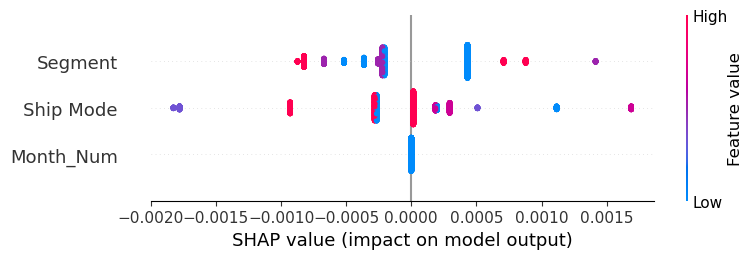

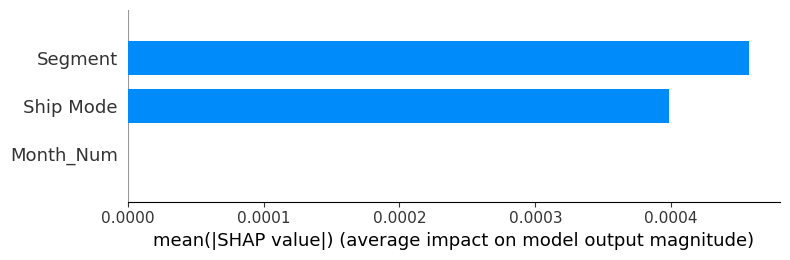

In [75]:
## linear reggression
import shap
import matplotlib.pyplot as plt
explainern=shap.TreeExplainer(rfc,x_train)
values =explainern(x_test)


shap.summary_plot(values,x_test)
shap.summary_plot(values,x_test,plot_type="bar")


In [76]:

rfc.fit(x_train,y_train)

C:\Users\VISWA\AppData\Local\Temp\ipykernel_5848\150303938.py:1: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rfc.fit(x_train,y_train)


RandomForestRegressor(n_estimators=10, random_state=42)

In [77]:
y_pred=rfc.predict(x_test)
y_pred

array([0.0102491 , 0.0102491 , 0.00750564, ..., 0.00989064, 0.0092996 ,
       0.0092996 ])

In [78]:
from sklearn.tree import DecisionTreeRegressor
dtr=DecisionTreeRegressor(max_depth=6,random_state=42)
dtr

DecisionTreeRegressor(max_depth=6, random_state=42)

In [79]:
dtr.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=6, random_state=42)

[Text(0.4861111111111111, 0.9166666666666666, 'Segment <= 0.5\nsquared_error = 0.001\nsamples = 6860\nvalue = 0.009'),
 Text(0.2222222222222222, 0.75, 'Ship Mode <= 1.5\nsquared_error = 0.001\nsamples = 3538\nvalue = 0.01'),
 Text(0.1111111111111111, 0.5833333333333334, 'Ship Mode <= 0.5\nsquared_error = 0.001\nsamples = 746\nvalue = 0.008'),
 Text(0.05555555555555555, 0.4166666666666667, 'squared_error = 0.001\nsamples = 535\nvalue = 0.008'),
 Text(0.16666666666666666, 0.4166666666666667, 'squared_error = 0.0\nsamples = 211\nvalue = 0.008'),
 Text(0.3333333333333333, 0.5833333333333334, 'Ship Mode <= 2.5\nsquared_error = 0.001\nsamples = 2792\nvalue = 0.01'),
 Text(0.2777777777777778, 0.4166666666666667, 'squared_error = 0.001\nsamples = 711\nvalue = 0.009'),
 Text(0.3888888888888889, 0.4166666666666667, 'squared_error = 0.001\nsamples = 2081\nvalue = 0.01'),
 Text(0.75, 0.75, 'Ship Mode <= 2.5\nsquared_error = 0.001\nsamples = 3322\nvalue = 0.009'),
 Text(0.6111111111111112, 0.583333

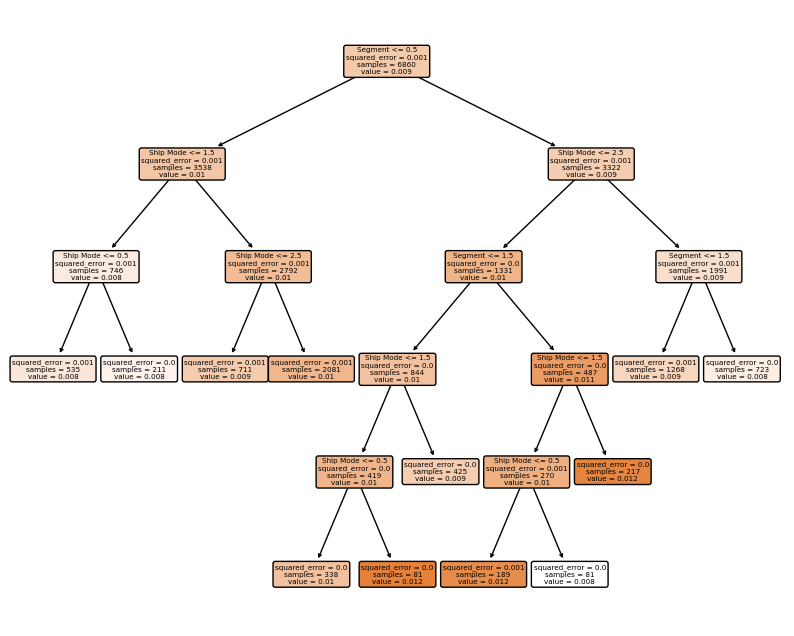

In [80]:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,8))
plot_tree(dtr,filled=True,feature_names=['Segment','Ship Mode','Month_Num'],class_names=['No.of.Sales'],rounded=True)

In [81]:
y_pred=dtr.predict(x_test)
y_pred

array([0.01014734, 0.01014734, 0.00803696, ..., 0.00946116, 0.0090567 ,
       0.0090567 ])

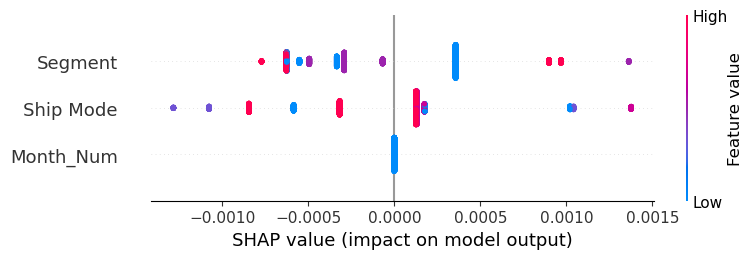

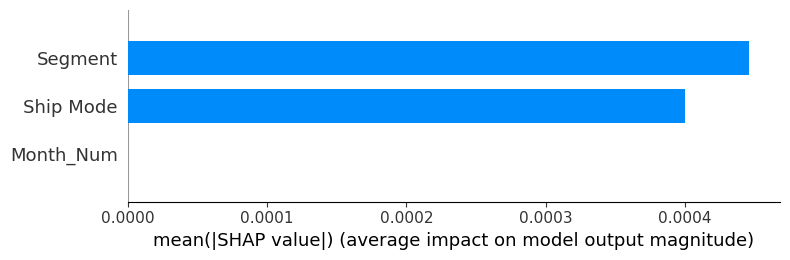

In [82]:
## linear reggression
import shap
import matplotlib.pyplot as plt
explainern=shap.Explainer(dtr,x_train)
values =explainern(x_test)


shap.summary_plot(values,x_test)
shap.summary_plot(values,x_test,plot_type="bar")
shap.initjs()
shap.force_plot(values[0].base_values,values[0].values,x_test.iloc[0])

In [83]:
from sklearn.ensemble import AdaBoostRegressor
abr=AdaBoostRegressor(n_estimators=10,random_state=42)
abr

AdaBoostRegressor(n_estimators=10, random_state=42)

In [84]:
abr.fit(x_train,y_train)

c:\Users\VISWA\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


AdaBoostRegressor(n_estimators=10, random_state=42)

In [85]:
y_pred=abr.predict(x_test)
y_pred

array([0.01011348, 0.01011348, 0.00677437, ..., 0.01011348, 0.00881138,
       0.00881138])

In [86]:
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(r2_score)
print(mse)
print(mae)
print(rmse)

<function r2_score at 0x000001DE1F120A40>
0.0011951948362747657
0.012992553862906216
0.03457159001658393


In [87]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [88]:
#cross validation
from sklearn.model_selection import cross_val_score
score=cross_val_score(lr,x_train,y_train,scoring='r2',cv=5)
score

array([-1.74959717e-03, -6.30224973e-06, -1.42006051e-03, -8.70861492e-04,
       -2.96951179e-03])

In [89]:
from sklearn.model_selection import cross_val_score
score=cross_val_score(lr,x_train,y_train,scoring='neg_mean_squared_error',cv=5)
score

array([-0.00113883, -0.00057556, -0.0004125 , -0.00047269, -0.00031957])

In [91]:
from xgboost import XGBRegressor
xg=XGBRegressor()
xg.fit(x_train,y_train)
xg_pred=xg.predict(x_test)
xg_pred

array([0.0100936 , 0.0100936 , 0.00818478, ..., 0.00946402, 0.00909294,
       0.00909294], dtype=float32)

In [92]:
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
xg_mae=mean_absolute_error(xg_pred,y_test)
print(xg_mae)
print("="*30)
xg_r2score=r2_score(y_test,xg_pred)
print(xg_r2score)
print("="*30)
xg_mse=mean_squared_error(y_test,y_pred)
print(xg_mse)
print("="*30)
xg_mae=mean_absolute_error(y_test,y_pred)
print(xg_mae)
print("="*30)
#cross_validation
from sklearn.model_selection import cross_val_score
score=cross_val_score(xg,x_train,y_train,scoring='neg_mean_squared_error',cv=5)
score


0.012970764199322868
-0.004411352880091535
0.0011951948362747657
0.012992553862906216


array([-0.00114005, -0.00057465, -0.00041131, -0.0004744 , -0.00031857])

In [93]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Assuming 'x' and 'y' are defined (Pandas DataFrame/Series)
# Normalize the data
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

# Convert 'y' to numpy array and reshape it for scaling
x_scaled = scaler_x.fit_transform(x)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# Reshape 'x' for LSTM input (LSTM expects 3D input: [samples, timesteps, features])
x_reshaped = np.reshape(x_scaled, (x_scaled.shape[0], 1, x_scaled.shape[1]))

# Train-test split
Xtrain, Xtest, ytrain, ytest = train_test_split(x_reshaped, y_scaled, test_size=0.2, random_state=42)

# Define LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(Xtrain.shape[1], Xtrain.shape[2])))
model.add(Dense(1))  # Output layer for regression
model.compile(optimizer='adam', loss='mse')

# Train the model
history = model.fit(Xtrain, ytrain, epochs=50, batch_size=32, validation_data=(Xtest, ytest), verbose=1)

# Make predictions
y_pred_scaled = model.predict(Xtest)
y_pred = scaler_y.inverse_transform(y_pred_scaled)  # Inverse transform predictions to original scale
ytest_original = scaler_y.inverse_transform(ytest)  # Inverse transform true values to original scale

# Evaluate the model
r2 = r2_score(ytest_original, y_pred)
mae = mean_absolute_error(ytest_original, y_pred)
mse = mean_squared_error(ytest_original, y_pred)

print(f"R2 Score: {r2}")
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")

Epoch 1/50


c:\Users\VISWA\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 9.9693e-04 - val_loss: 0.0013
Epoch 2/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9867e-04 - val_loss: 0.0013
Epoch 3/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.3016e-04 - val_loss: 0.0013
Epoch 4/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.6838e-04 - val_loss: 0.0013
Epoch 5/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1743e-04 - val_loss: 0.0013
Epoch 6/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.7765e-04 - val_loss: 0.0013
Epoch 7/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0189e-04 - val_loss: 0.0013
Epoch 8/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.4999e-04 - val_loss: 0.0013
Epoch 9/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.9773e-04 - val_loss: 0.0013
Epoch 10/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9225e-04 - val_loss: 0.0013
Epoch 11/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.4355e-04 - val_loss: 0.0013
Epoch 12/50
245/245

In [94]:
new_values = [[1,3,1]]
pred = lr.predict(new_values)
pred

c:\Users\VISWA\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[0.00946161]])

In [95]:
new_values = [[1,3,1]]
pred = rfc.predict(new_values)
pred

c:\Users\VISWA\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([0.0092996])

In [97]:
new_values = [[1,3,1]]
pred = xg.predict(new_values)
pred

array([0.00909294], dtype=float32)

In [98]:
## joblib
import joblib
joblib.dump(lr,"linear.joblib")
joblib.dump(dtr,"decision.joblib")
joblib.dump(rfc,"ranodm.joblib")
joblib.dump(xg,"xgb.joblib")

['xgb.joblib']

In [100]:
model=joblib.load("Ranodm.joblib")
new_values=[[1,3,1]]
pred=model.predict(new_values)
pred

c:\Users\VISWA\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([0.0092996])

In [108]:
model = joblib.load("rfc_model.pkl")
new_values = [[1,3,1]]
pred = model.predict(new_values)
pred

c:\Users\VISWA\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([0.0092996])

In [105]:
import pickle
with open("rfc_model.pkl","wb") as fe:
    model = pickle.dump(rfc,fe)

In [106]:
print(model)

None
